# LAB | Feature Engineering

**Load the data**

In this challenge, we will be working with the same Spaceship Titanic data, like the previous Lab. The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

In [20]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [21]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**Check the shape of your data**

In [22]:
#your code here
print(spaceship.shape)

(8693, 14)


**Check for data types**

In [23]:
#your code here
spaceship.info()

print(spaceship.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float6

**Check for missing values**

In [24]:
#your code here
print(spaceship.isna().sum())

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


There are multiple strategies to handle missing data

- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

For this exercise, because we have such low amount of null values, we will drop rows containing any missing value. 

In [25]:
#your code here

# fill missing values with mean in continuos variables
spaceship["Age"].fillna(spaceship["Age"].mean(), inplace=True)
spaceship["RoomService"].fillna(spaceship["RoomService"].mean(), inplace=True)
spaceship["FoodCourt"].fillna(spaceship["FoodCourt"].mean(), inplace=True)
spaceship["ShoppingMall"].fillna(spaceship["ShoppingMall"].mean(), inplace=True)
spaceship["Spa"].fillna(spaceship["Spa"].mean(), inplace=True)
spaceship["VRDeck"].fillna(spaceship["VRDeck"].mean(), inplace=True)

# fill missing values with mode in categorical variables
spaceship["HomePlanet"].fillna(spaceship["HomePlanet"].mode()[0], inplace=True)
spaceship["CryoSleep"].fillna(spaceship["CryoSleep"].mode()[
0], inplace=True)
spaceship["Cabin"].fillna(spaceship["Cabin"].mode()[0], inplace=True)
spaceship["Destination"].fillna(spaceship["Destination"].mode()[
0], inplace=True)
spaceship["VIP"].fillna(spaceship["VIP"].mode()[0], inplace=True)
spaceship["Name"].fillna(spaceship["Name"].mode()[0], inplace=True)
    

C:\Users\pauli\AppData\Local\Temp\ipykernel_34716\2318966804.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  spaceship["Age"].fillna(spaceship["Age"].mean(), inplace=True)
C:\Users\pauli\AppData\Local\Temp\ipykernel_34716\2318966804.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

- **Cabin** is too granular - transform it in order to obtain {'A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'}

In [26]:
#your code here

spaceship["Cabin"] = spaceship["Cabin"].apply(lambda x: x[0])

print(spaceship["Cabin"].unique())
    

['B' 'F' 'A' 'G' 'E' 'D' 'C' 'T']


- Drop PassengerId and Name

In [27]:
#your code here

spaceship.drop(["PassengerId", "Name"], axis=1, inplace=True)

print(spaceship.columns)


Index(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP',
       'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Transported'],
      dtype='object')


- For non-numerical columns, do dummies.

In [28]:
#your code here

spaceship = pd.get_dummies(spaceship, drop_first=True)
print(spaceship.columns)


Index(['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall',
       'Spa', 'VRDeck', 'Transported', 'HomePlanet_Europa', 'HomePlanet_Mars',
       'Cabin_B', 'Cabin_C', 'Cabin_D', 'Cabin_E', 'Cabin_F', 'Cabin_G',
       'Cabin_T', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e'],
      dtype='object')


**Perform Train Test Split**

In [29]:
#your code here

X = spaceship.drop("Transported", axis=1)
y = spaceship["Transported"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(6954, 19)
(1739, 19)
(6954,)
(1739,)


**Model Selection**

In this exercise we will be using **KNN** as our predictive model.

In [32]:
#your code here

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(y_pred)   

[False  True  True ... False  True False]


- Evaluate your model's performance. Comment it

Accuracy: 0.757906843013226
Classification Report:
               precision    recall  f1-score   support

       False       0.77      0.74      0.75       861
        True       0.75      0.78      0.76       878

    accuracy                           0.76      1739
   macro avg       0.76      0.76      0.76      1739
weighted avg       0.76      0.76      0.76      1739

Confusion Matrix:
 [[634 227]
 [194 684]]
AUC-ROC: 0.8369241412882726


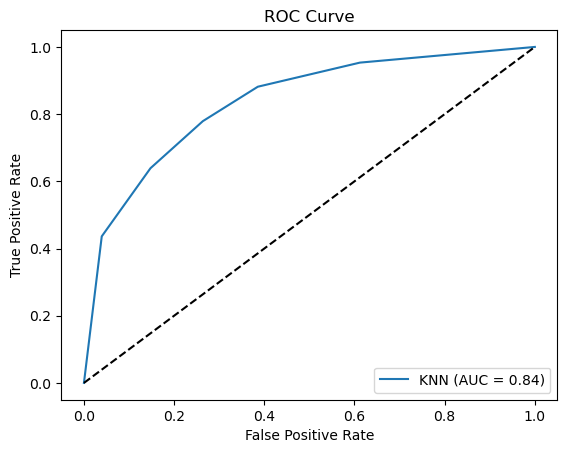

In [ ]:

#your code here

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# print auc-roc curve
from sklearn.metrics import roc_auc_score, roc_curve
y_prob = knn.predict_proba(X_test)[:, 1]

auc_roc = roc_auc_score(y_test, y_prob)
print("AUC-ROC:", auc_roc)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, label="KNN (AUC = {:.2f})".format(auc_roc))
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
